# TOPIC for Causal Discovery in Topological Order

Demo of TOPIC.




In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from causalchange.causal_change import CausalChange
from causalchange.config.cc_types import (
    ContextAggregation,
    DataMode,
    GPType,
    GraphSearch,
)
from causalchange.plotting import plot_graph

## 1. Synthetic nonlinear data



In [3]:
true_edges = {
    ("x0", "x1"),
    ("x0", "x2"),
    ("x1", "x3"),
    ("x2", "x3"),
    ("x3", "x4"),
}


def standardize(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean(axis=0)) / df.std(axis=0)


def simulate_topic_data(
    n: int = 800,
    seed: int = 42,
    noise_scale: float = 0.30,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    x0 = rng.normal(size=n)

    x1 = np.tanh(1.4 * x0) + rng.normal(scale=noise_scale, size=n)
    x2 = 0.6 * x0**2 + 0.3 * x0 + rng.normal(scale=noise_scale, size=n)
    x3 = np.sin(x1) + 0.7 * x2 + rng.normal(scale=noise_scale, size=n)
    x4 = np.tanh(x3) + rng.normal(scale=noise_scale, size=n)

    X = pd.DataFrame(
        {
            "x0": x0,
            "x1": x1,
            "x2": x2,
            "x3": x3,
            "x4": x4,
        }
    )

    return standardize(X)


X = simulate_topic_data()
X.head()

,x0,x1,x2,x3,x4
0,0.338838,0.226698,-0.469107,-0.254715,-0.334313
1,-1.027287,-1.534139,0.134625,-0.513059,0.032722
2,0.791674,1.172615,0.428309,1.057422,0.987499
3,0.984816,1.293777,-0.186324,0.475195,1.327328
4,-1.952852,-0.742148,1.160720,-0.079520,0.386492


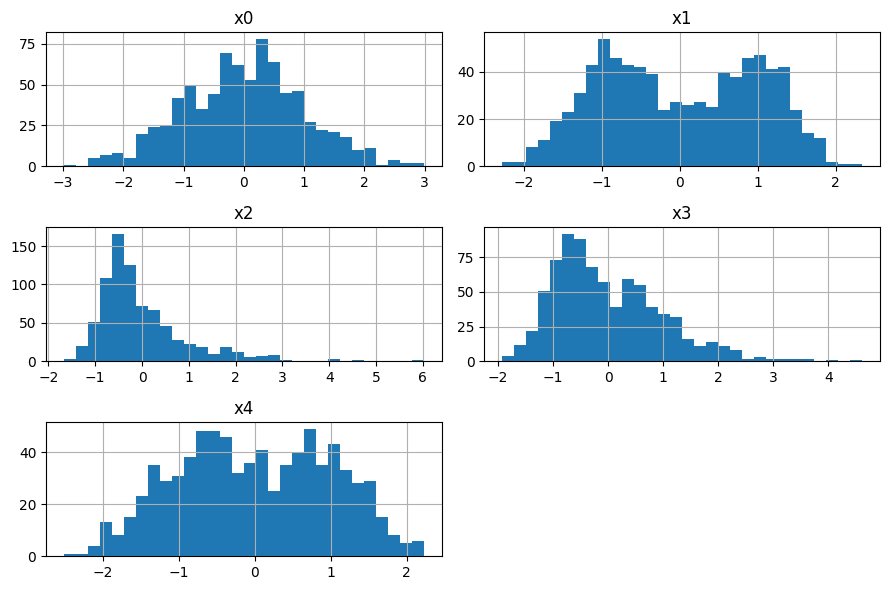

In [4]:
axes = X.hist(figsize=(9, 6), bins=30)
plt.tight_layout()
plt.show()

## 2. Run TOPIC


In [5]:
cc_topic = CausalChange(
    data_mode=DataMode.IID,
    graph_search=GraphSearch.TOPIC,
    score_type=GPType.FOURIER,
    aggregation=ContextAggregation.SKIP,
    score_kwargs={
        "D": 128,
        "restarts": 2,
        "refine": False,
        "seed": 42,
    },
)

cc_topic.fit(X)

print("Topological order:")
print(cc_topic.topological_order_)

print("\nEstimated edges:")
for edge in sorted(cc_topic.graph_.edges()):
    print("  ", edge)

print("\nEdge strengths:")
pd.Series(cc_topic.result_.edge_strengths, name="strength").sort_values(ascending=False)

Topological order:
['x0', 'x2', 'x1', 'x3', 'x4']

Estimated edges:
   ('x0', 'x1')
   ('x0', 'x2')
   ('x1', 'x3')
   ('x2', 'x3')
   ('x3', 'x4')

Edge strengths:


x0  x2    1160.458705
    x1    1039.767614
x3  x4     875.069306
x1  x3     814.681260
x2  x3     761.187565
Name: strength, dtype: float64

## 3. Eval



In [6]:
def edge_recovery_summary(estimated_edges, true_edges):
    estimated_edges = set(estimated_edges)
    true_edges = set(true_edges)

    tp = estimated_edges & true_edges
    fp = estimated_edges - true_edges
    fn = true_edges - estimated_edges

    precision = len(tp) / max(len(tp) + len(fp), 1)
    recall = len(tp) / max(len(tp) + len(fn), 1)

    return {
        "precision": precision,
        "recall": recall,
        "true_positives": sorted(tp),
        "false_positives": sorted(fp),
        "false_negatives": sorted(fn),
    }


summary = edge_recovery_summary(cc_topic.graph_.edges(), true_edges)
summary

{'precision': 1.0,
 'recall': 1.0,
 'true_positives': [('x0', 'x1'),
  ('x0', 'x2'),
  ('x1', 'x3'),
  ('x2', 'x3'),
  ('x3', 'x4')],
 'false_positives': [],
 'false_negatives': []}

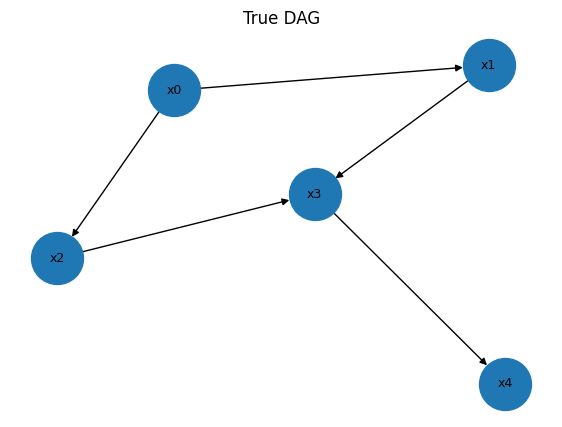

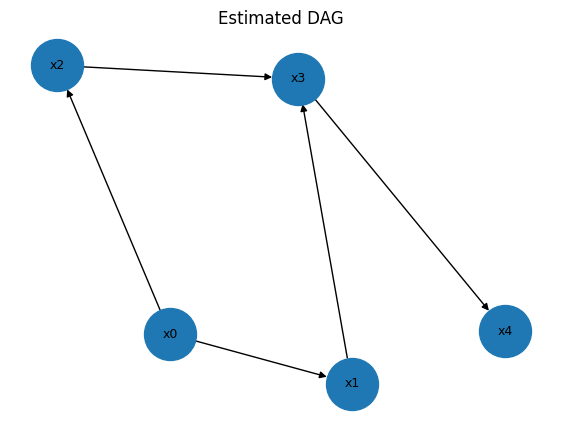

In [7]:
true_graph = nx.DiGraph()
true_graph.add_edges_from(true_edges)

plot_graph(true_graph, title="True DAG")
plt.show()

plot_graph(cc_topic.graph_, title="Estimated DAG")
plt.show()